In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# --------------------------------------------------------------------------
# 1. DATA LOADING & PREPROCESSING
# --------------------------------------------------------------------------

def load_and_clean(csv_path: str) -> pd.DataFrame:
    """Load styles.csv and apply the preprocessing pipeline."""
    df = pd.read_csv(csv_path, on_bad_lines="skip")
    print(f"[1/4] Raw dataset shape: {df.shape}")

    # --- Missing value handling ---
    df = df.dropna(subset=["productDisplayName"]).reset_index(drop=True)

    # Secondary attributes: impute with empty string
    # REVISI: Tambahkan 'season' dan 'year' agar tidak error saat digabungkan
    secondary_cols = ["gender", "masterCategory", "subCategory",
                      "articleType", "baseColour", "usage", "season", "year"]
    for col in secondary_cols:
        df[col] = df[col].fillna("")

    print(f"[2/4] Shape after missing-value handling: {df.shape}")

    # --- REVISI: Modifikasi productDisplayName ---
    # Konversi year ke string dan hilangkan desimal '.0' jika pandas membacanya sebagai float
    df["year_str"] = df["year"].astype(str).str.replace(r'\.0$', '', regex=True)

    # Format baru: "Nama Produk Asli (Season Year)"
    df["productDisplayName"] = df["productDisplayName"] + " (" + df["season"] + " " + df["year_str"] + ")"

    # Bersihkan spasi berlebih atau tanda kurung kosong " ()" jika season/year kebetulan kosong
    df["productDisplayName"] = df["productDisplayName"].str.replace(r'\(\s*\)', '', regex=True).str.strip()

    # REVISI: Hapus baris jika nama produk barunya masih duplikat sempurna agar hasil rekomendasi lebih bervariasi
    df = df.drop_duplicates(subset=["productDisplayName"]).reset_index(drop=True)

    # --- Feature engineering: build the "metadata soup" ---
    # Masukkan juga season dan year ke dalam metadata untuk menambah akurasi TF-IDF
    text_cols = ["productDisplayName", "gender", "masterCategory",
                 "subCategory", "articleType", "baseColour", "usage", "season", "year_str"]
    df["tags"] = df[text_cols].agg(" ".join, axis=1)

    # --- Case folding ---
    df["tags"] = df["tags"].str.lower()

    # --- Punctuation / noise removal via regex ---
    df["tags"] = df["tags"].apply(lambda x: re.sub(r"[^a-z0-9\s]", " ", x))
    df["tags"] = df["tags"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

    print(f"[3/4] Example cleaned tag: '{df['tags'].iloc[0]}'")
    print(f"[4/4] Final clean corpus size: {df.shape[0]} products")
    return df


# --------------------------------------------------------------------------
# 2. FEATURE EXTRACTION + MODEL FITTING
# --------------------------------------------------------------------------

def build_tfidf_knn(df: pd.DataFrame, n_neighbors: int = 6):
    """Fit TF-IDF vectorizer + Unsupervised KNN (cosine distance)."""
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["tags"])
    print(f"TF-IDF matrix shape: {tfidf_matrix.shape} "
          f"(vocabulary size = {tfidf_matrix.shape[1]})")

    knn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
    knn.fit(tfidf_matrix)
    return tfidf, tfidf_matrix, knn


# --------------------------------------------------------------------------
# 3. RECOMMENDATION FUNCTION
# --------------------------------------------------------------------------

def recommend(product_id, df, tfidf_matrix, knn, k=5):
    """Return the top-K most similar products to a given product id."""
    idx = df.index[df["id"] == product_id]
    if len(idx) == 0:
        raise ValueError(f"Product id {product_id} not found in dataset.")
    idx = idx[0]

    distances, indices = knn.kneighbors(tfidf_matrix[idx], n_neighbors=k + 1)
    indices = indices[0][1:]        # drop the anchor itself
    similarities = 1 - distances[0][1:]

    # Menampilkan season dan year di tabel hasil akhir sebagai bukti atribut tambahan
    results = df.iloc[indices][
        ["id", "productDisplayName", "articleType", "baseColour", "usage", "season", "year_str"]
    ].copy()

    # Rename year_str kembali menjadi year untuk tampilan
    results = results.rename(columns={"year_str": "year"})
    results["cosine_similarity"] = similarities
    return results.reset_index(drop=True)


# --------------------------------------------------------------------------
# 4. EVALUATION: Precision@K, Recall@K, NDCG@K
# --------------------------------------------------------------------------

def evaluate(df, tfidf_matrix, knn, k=5, n_samples=3000, relevance_col="articleType",
             random_seed=42):
    """Evaluate the recommender using a category-based relevance proxy."""
    rng = np.random.default_rng(random_seed)
    n = df.shape[0]
    sample_idx = rng.choice(n, size=min(n_samples, n), replace=False)

    labels = df[relevance_col].values
    label_counts = df[relevance_col].value_counts().to_dict()

    precisions, recalls, ndcgs = [], [], []

    for idx in sample_idx:
        _, indices = knn.kneighbors(tfidf_matrix[idx], n_neighbors=k + 1)
        indices = indices[0][1:]  # drop anchor itself

        anchor_label = labels[idx]
        relevance = (labels[indices] == anchor_label).astype(int)

        # Precision@K
        precisions.append(relevance.sum() / k)

        # Recall@K
        total_relevant = label_counts.get(anchor_label, 1) - 1
        denom = min(k, total_relevant) if total_relevant > 0 else 1
        recalls.append(relevance.sum() / denom)

        # NDCG@K
        dcg = sum(r / np.log2(i + 2) for i, r in enumerate(relevance))
        ideal = sorted(relevance, reverse=True)
        idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        "relevance_granularity": relevance_col,
        "k": k,
        "n_samples": len(sample_idx),
        "precision_at_k": float(np.mean(precisions)),
        "recall_at_k": float(np.mean(recalls)),
        "ndcg_at_k": float(np.mean(ndcgs)),
    }


# --------------------------------------------------------------------------
# 5. EKSEKUSI UTAMA (Pengganti argparse)
# --------------------------------------------------------------------------

CONFIG_CSV = "styles.csv"
CONFIG_K = 5
CONFIG_N_SAMPLES = 3000
CONFIG_EXAMPLE_ID = None  # Coba ganti ke angka ID dari excel, misal 15970

print("Mulai memproses dataset...")

# 1) Load & preprocess
df = load_and_clean(CONFIG_CSV)

# 2) Build TF-IDF + KNN
tfidf, tfidf_matrix, knn = build_tfidf_knn(df, n_neighbors=CONFIG_K + 1)

# 3) Example recommendation
example_id = CONFIG_EXAMPLE_ID or df["id"].iloc[0]
print(f"\n=== Example: Top-{CONFIG_K} recommendations for product id {example_id} ===")
# Cetak dengan format yang lebih rapi
print(recommend(example_id, df, tfidf_matrix, knn, k=CONFIG_K).to_string(index=False))

# 4) Evaluation at two relevance granularities
print(f"\n=== Evaluation (K={CONFIG_K}, n_samples={CONFIG_N_SAMPLES}) ===")
for col in ["articleType", "subCategory"]:
    result = evaluate(df, tfidf_matrix, knn, k=CONFIG_K,
                       n_samples=CONFIG_N_SAMPLES, relevance_col=col)
    print(f"[{col}] Precision@{CONFIG_K} = {result['precision_at_k']:.4f}  |  "
          f"Recall@{CONFIG_K} = {result['recall_at_k']:.4f}  |  "
          f"NDCG@{CONFIG_K} = {result['ndcg_at_k']:.4f}")

Mulai memproses dataset...
[1/4] Raw dataset shape: (44424, 10)
[2/4] Shape after missing-value handling: (44417, 10)
[3/4] Example cleaned tag: 'turtle check men navy blue shirt fall 2011 men apparel topwear shirts navy blue casual fall 2011'
[4/4] Final clean corpus size: 32689 products
TF-IDF matrix shape: (32689, 8595) (vocabulary size = 8595)

=== Example: Top-5 recommendations for product id 15970 ===
   id                              productDisplayName articleType baseColour  usage season year  cosine_similarity
15996         Turtle Check Men Blue Shirt (Fall 2011)      Shirts       Blue Casual   Fall 2011           0.858548
 7172  Scullers Men Navy Blue Check Shirt (Fall 2011)      Shirts  Navy Blue Casual   Fall 2011           0.831037
26396  Turtle Men Check Navy Blue Shirt (Summer 2012)      Shirts  Navy Blue Formal Summer 2012           0.826363
23667    Spykar Men Navy Blue Check Shirt (Fall 2011)      Shirts  Navy Blue Casual   Fall 2011           0.823288
11692 Lee Men 

In [ ]:
import time
t0 = time.time()
tfidf, tfidf_matrix, knn = build_tfidf_knn(df, n_neighbors=CONFIG_K + 1)
print(f"Fitting time: {time.time() - t0:.3f} seconds")

TF-IDF matrix shape: (32689, 8595) (vocabulary size = 8595)
Fitting time: 1.498 seconds


Mulai membuat Word Cloud dari Metadata Soup...


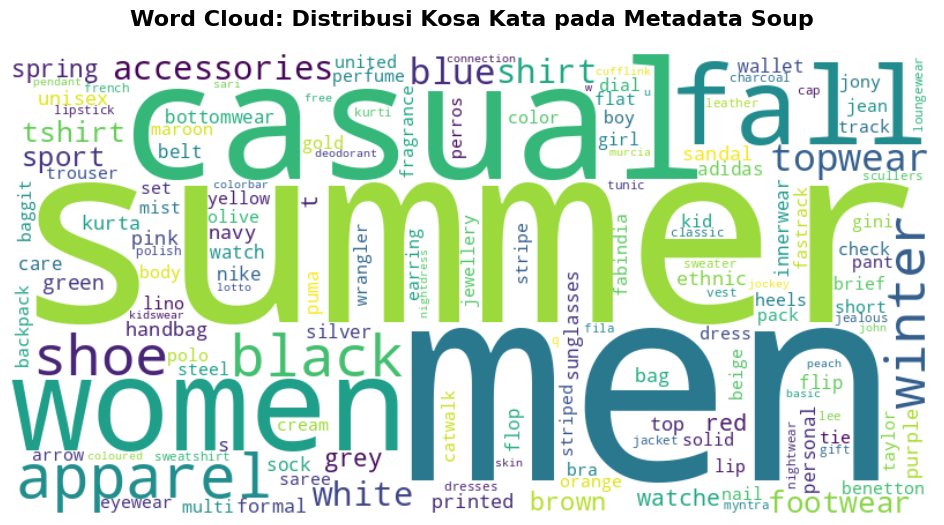

In [ ]:
# Install library wordcloud jika belum ada di Colab (biasanya sudah ada bawaan)
# !pip install wordcloud matplotlib

import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("Mulai membuat Word Cloud dari Metadata Soup...")

# 1. Gabungkan seluruh teks dari kolom 'tags' (metadata soup) menjadi satu string panjang
all_text = " ".join(df["tags"].values)

# 2. Konfigurasi dan Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',      # Tema warna yang profesional dan kontras
    max_words=150,           # Menampilkan maksimal 150 kata paling dominan
    collocations=False       # Mematikan penggabungan kata ganda agar lebih akurat
).generate(all_text)

# 3. Plot dan Tampilkan Gambar
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Menghilangkan garis sumbu X dan Y agar bersih
plt.title("Word Cloud: Distribusi Kosa Kata pada Metadata Soup", fontsize=16, fontweight='bold', pad=20)
plt.show()

Mulai membuat visualisasi EDA...


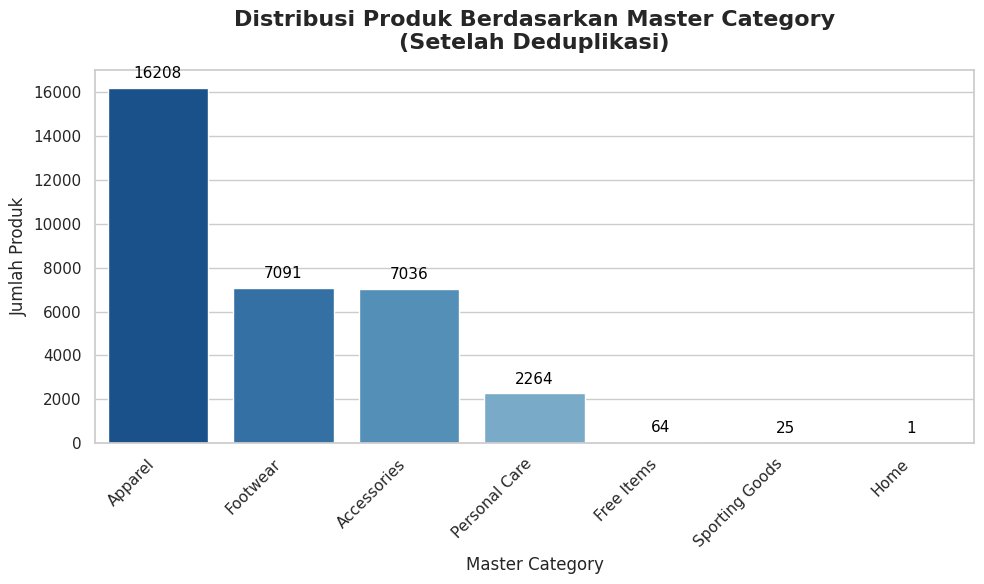

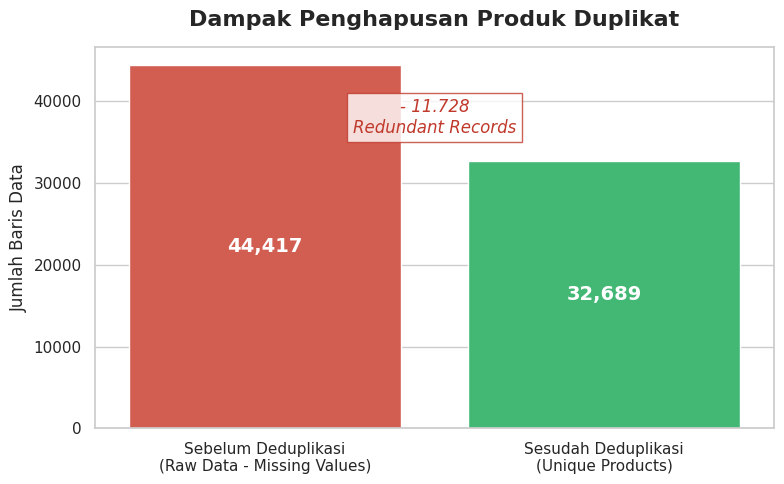

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Mulai membuat visualisasi EDA...")

# Setel gaya grafik agar terlihat profesional
sns.set_theme(style="whitegrid")

# ===================================================================
# EDA 1: Distribusi Produk Berdasarkan Master Category
# Target jumlah: Apparel ~16208, Footwear ~7091, Accessories ~7036
# ===================================================================
plt.figure(figsize=(10, 6))
cat_counts = df['masterCategory'].value_counts()

# PERBAIKAN: Menambahkan parameter 'hue' dan 'legend=False' agar warning Seaborn hilang
ax = sns.barplot(
    x=cat_counts.index,
    y=cat_counts.values,
    hue=cat_counts.index,
    palette="Blues_r",
    legend=False
)

plt.title('Distribusi Produk Berdasarkan Master Category\n(Setelah Deduplikasi)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Master Category', fontsize=12)
plt.ylabel('Jumlah Produk', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Menambahkan angka jumlah tepat di atas batang grafik
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# ===================================================================
# EDA 2: Komparasi Ukuran Dataset Sebelum vs Sesudah Deduplikasi
# ===================================================================
plt.figure(figsize=(8, 5))

kondisi = ['Sebelum Deduplikasi\n(Raw Data - Missing Values)', 'Sesudah Deduplikasi\n(Unique Products)']
jumlah = [44417, 32689]

# PERBAIKAN: Menambahkan parameter 'hue' dan 'legend=False'
ax2 = sns.barplot(
    x=kondisi,
    y=jumlah,
    hue=kondisi,
    palette=["#e74c3c", "#2ecc71"],
    legend=False
)

plt.title('Dampak Penghapusan Produk Duplikat', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Jumlah Baris Data', fontsize=12)

# Menambahkan angka di dalam grafik
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}",
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center',
                 fontsize=14, fontweight='bold', color='white')

# Menambahkan keterangan selisih
plt.text(0.5, 38000, "- 11.728\nRedundant Records", ha='center', va='center',
         fontsize=12, style='italic', color='#c0392b',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#c0392b'))

plt.tight_layout()
plt.show()